# ALD - TME 13: Physics-Informed Neural Networks (PINNs)


# Observations

**Exercise 1: Standard PINN (data + physics residual)** <br>
All trainings were done using 5k training epochs using an ADAM optimizer followed by 200 training epochs using the L-BFGS optimizer for refinement.
- The resulting predictions almost perfectly match the reference Burgers solution.
- There are only small errors near the 'shock' region where results drop as gradients should be higher in that region.
- It is the physics residual term that allows the model to generalize its predictions across the whole spatio-temporal space, so removing the physics residual term from the loss term ruins the generalization we see in the first training pass of the model, it now only fits the training data, which explains the consistent error across the spatio-temporal space that we see in the error plot.

**Exercise 2: Standard PINN with physical parameters estimations** <br>
- a and v are very small value parameters so the NN can optimize more easily by modify the value of solution u rather than a and v
- They also aren't directly learnable from the supervised loss
- So, for the model to successfully learn them, we need to focus more on the physical residual loss term
- To have succesful results, I increased the weight put on the physical residual term of the loss (lamba_f = 100 vs lambda_u = 1)
- We also add more supervised data points and sample from whithin the spatio-temporal space instead of the boundary since we now focus on learning the parameters rather than the whole space dynamics and interior dynamics carry more information about the physical parameters than boundary ones
- Finally we normalize the supervised data to try and stabilize the results
- We end up getting results that are in a realistic range but not too accurate after 6000 epochs using ADAM: <br>
<div style="text-align: center;">
$v=0.986$
</div>
<div style="text-align: center;">
and
</div>
<div style="text-align: center;">
$a=0.050$
</div>

In [134]:
# Fix for Jupyter kernel CWD issue: ensure current working directory exists
# This prevents errors in both our code and PyTorch's internal code (e.g., LBFGS optimizer)
# PyTorch's LBFGS optimizer calls os.getcwd() internally, which fails if CWD doesn't exist
import os
from pathlib import Path

try:
    # Try to access current working directory
    cwd = os.getcwd()
    # Verify the directory actually exists
    if not Path(cwd).exists():
        raise FileNotFoundError(f"Current working directory does not exist: {cwd}")
except (OSError, FileNotFoundError):
    # If CWD doesn't exist or is inaccessible, set it to a safe location
    # Use home directory as a reliable fallback
    safe_dir = Path.home()
    # Ensure the safe directory exists and change to it
    safe_dir.mkdir(parents=True, exist_ok=True)
    os.chdir(str(safe_dir))
    print(f"Warning: Current working directory was invalid. Changed to: {os.getcwd()}")

import torch
import torch.nn as nn
import torch.functional as F
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
from mpl_toolkits.axes_grid1 import make_axes_locatable
from contextlib import contextmanager
from functools import partial
import urllib.request
import math


# Device selection: prefer MPS (Apple Silicon) > CUDA > CPU
# Note: MPS can be unstable in some environments, use CPU if issues occur
try:
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
except Exception as e:
    # Fallback to CPU if device selection fails
    print(f"Warning: Device selection failed ({e}), using CPU")
    device = torch.device("cpu")

print(f"Using device: {device}")

np.random.seed(1234)

Using device: cuda



## As a case study, we will apply PINNs on the Burgers equations, following this PDE:

[From Wikipedia](https://en.wikipedia.org/wiki/Burgers%27_equation)

> Burgers' equation or Bateman-Burgers equation is a fundamental partial
> differential equation and convection-diffusion equation occurring in various
> areas of applied mathematics, such as fluid mechanics, nonlinear acoustics,
> gas dynamics, and traffic flow. The equation was first introduced by Harry
> Bateman in 1915 and later studied by Johannes Martinus Burgers in 1948.

The equation is as follows

$$\frac{\partial u(x,t)}{\partial t} + a ~ u(x,t)  ~ \frac{\partial
u(x,t)}{\partial x} - \nu  ~  \frac{\partial^2 u(x,t)}{\partial x^2} =0$$
where $u(x,t)$ is the field (e.g. speed of the fluid at the location $x$ and
time $t$). We will get the solution of this PDE with  the friction coefficient
setup to $\nu=\frac{0.01}{\pi}$, and $a=1.0$

**In PINNs, wa want to train a parametric data-driven model $f_{\theta}(x,t)$
to approximate $u(x,t)$ at any (x,t) position.**


# Loading the data
A pre-computed solution has been generated using the above equation for a
series of times ($t$) and positions ($x$). The `Exact` tensor is a
time x position matrix, while `t` and `x` are resp. the different values
for time and position.

In [271]:

# Data file path - CWD is now guaranteed to be valid from the fix above
data_file = Path("burgers_shock.mat")

if not data_file.is_file():
    print("Downloading the data...")
    # Ensure parent directory exists
    data_file.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/maziarraissi/PINNs/master/appendix/Data/burgers_shock.mat",
        str(data_file),
    )


data = scipy.io.loadmat(str(data_file))

t = torch.Tensor(data["t"].flatten())
x = torch.Tensor(data["x"].flatten())
Exact = torch.Tensor(data["usol"]).T
extent = [t.min(), t.max(), x.min(), x.max()]

print(f"t: {t.shape}")
print(f"x: {x.shape}")
print(f"Exact: {Exact.shape}")
print(Exact)

t: torch.Size([100])
x: torch.Size([256])
Exact: torch.Size([100, 256])
tensor([[ 1.2246e-16,  2.4637e-02,  4.9260e-02,  ..., -4.9260e-02,
         -2.4637e-02, -1.2246e-16],
        [ 2.9536e-17,  2.3880e-02,  4.7747e-02,  ..., -4.7747e-02,
         -2.3880e-02, -1.0854e-16],
        [ 1.0847e-16,  2.3168e-02,  4.6325e-02,  ..., -4.6325e-02,
         -2.3168e-02, -1.2938e-16],
        ...,
        [ 3.5730e-16,  6.0765e-03,  1.2153e-02,  ..., -1.2153e-02,
         -6.0765e-03,  1.0488e-16],
        [ 2.6183e-16,  6.0297e-03,  1.2059e-02,  ..., -1.2059e-02,
         -6.0297e-03,  2.1751e-16],
        [ 9.3954e-17,  5.9837e-03,  1.1967e-02,  ..., -1.1967e-02,
         -5.9837e-03,  1.1239e-16]])



## **Plot the evolution of the solution u(x,t) over time.**

In the figure below, we plot the evolution of $u$ (given in `Exact`) over time (given in `t`, x-axis) and $x$ (given in `x`, y-axis).

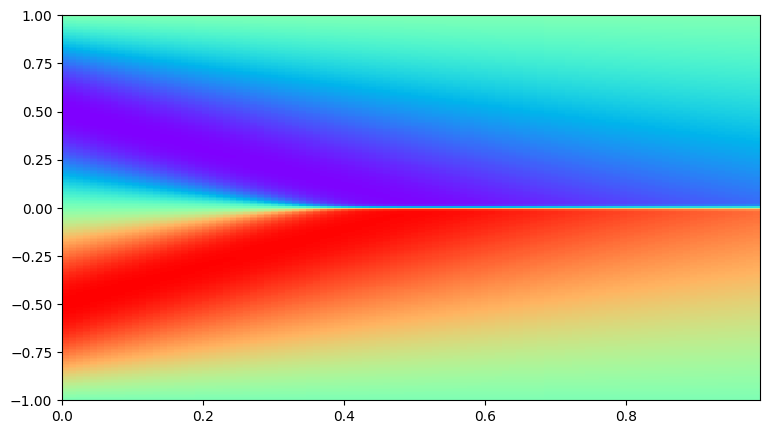

In [272]:
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)
h = ax.imshow(
    Exact.T,
    interpolation="nearest",
    cmap="rainbow",
    extent=[t.min(), t.max(), x.min(), x.max()],
    origin="lower",
    aspect="auto",
)


# Exercice 1: learning the solution with physics-informed constraints

In PINNs, we want to train a parametric data-driven model $f_{\theta}(x,t)$ to approximate $u(x,t)$ at any (x,t) position. PINNs combine two losses during training:

## Supervised loss

A supervised loss, where we have $N_u$ labeled points $\left\{(x_i,t_i,u_i)\right\}_{i \in \left\{ 1 ; N \right\}}$. We use the standard MSE loss between the model prediction $f_{\theta}(x_i,t_i)$ and the ground truth $u_i$:
$$l_u(\theta) = \frac{1}{N_u} \sum\limits_{i=1}^{N_u} \left[f_{\theta}(x_i,t_i)-u_i(x_i,t_i)\right]^2$$
In the first exercice, we randomly sample $N_u=100$ points **in the boundary layer** - $(x_{min},t)$, $(x_{max},t)$ and in initial condtions $(x,0)$.

## Unsupervised loss

For the unsupervised loss, we randomly sample $N_f$ points in the $(x,t)$ interval, and enforce the learned function $f_{\theta}$ to fulfill the PDE. Let us define
$$h_\theta(x,t) = \frac{\partial f_{\theta}(x,t)}{\partial t} + f_{\theta}(x,t) \frac{\partial f_{\theta}(x,t)}{\partial x} - \nu \frac{\partial^2 f_{\theta}(x,t)}{\partial x^2}$$
We can define the following unsupervised loss
$$l_f(\theta) = \frac{1}{N_f} \sum\limits_{i=1}^{N_f} \left[h_{\theta}(x_i,t_i)\right]^2 $$

The final loss in PINNs will be a combination of both supervised and unsupervised  losses:

$$
\mathcal{L}(\theta) = \lambda_u l_u(\theta) + \lambda_fl_f(\theta)
$$

## **1.1) Collect labeled data and unlabeled physics-informed constraint data.**

In the code below, you will collect $N_u$ supervised data points and $N_f$ unsupervised ones. It should set the following values:

- `X_u_train` is a matrix $N_u \times 2$ (dimensions = $x$ and $t$)
- `u_train` is a vector with $u(x,t)$ values for $(x,t)$ couples in `X_u_train`
- `X_f_train` is a matrix $N_f \times 2$ (dimensions = $x$ and $t$)

In [273]:
# Creates a grid from x and t, of shape (time x position)
T, X = torch.meshgrid(t, x)

assert len(X) == len(t)
assert Exact.shape == T.shape, f"{Exact.shape} vs {T.shape}"

# Shape (N, 2)
X_star = torch.hstack((X.flatten().reshape(-1, 1), T.flatten().reshape(-1, 1)))
print(X_star.shape)

# u(x,t) for X_star
# [t*x, 2] -> [25600, 2]
u_star = Exact.flatten()
print(u_star.shape)

torch.Size([25600, 2])
torch.Size([25600])


In [274]:
###### Labeled points

N_u = 100  # Number of points to compute the prediction loss (MSE_u)

# À compléter...  

# filter through data points to gather boundary layer data points
X_star_sample = torch.Tensor(2)
u_star_sample = torch.Tensor(1)

for i in range(X_star.shape[0]):
    if X_star[i][1] == 0 or X_star[i][0] == x.min().item() or X_star[i][0] == x.max().item():
        X_star_sample = torch.cat((X_star_sample, X_star[i]))
        u_val = torch.Tensor([u_star[i]])
        u_star_sample = torch.cat((u_star_sample, u_val))

X_star_sample = X_star_sample.reshape(int(X_star_sample.shape[0]/2), 2)
u_star_sample = u_star_sample.reshape(u_star_sample.shape[0], 1)


# select 100 points that belong to the boundary:
idx = torch.randint(0, X_star_sample.size(0), (N_u,))

x_train = torch.Tensor([X_star_sample[i][0] for i in idx]).view(N_u, 1)
print("x_train shape: ", x_train.shape)

t_train = torch.Tensor([X_star_sample[i][1] for i in idx]).view(N_u, 1)
print("t_train shape: ", t_train.shape)

X_u_train = X_star_sample[idx]
print("x_u_train shape: ", X_u_train.shape)
 
u_train = torch.Tensor([u_star_sample[i] for i in idx]).view(N_u, 1)
print("u_train shape: ", u_train.shape)

# Some checks...

assert x_train.shape == (N_u, 1), f"{x_train.shape} != {(N_u, 1)}"
assert t_train.shape == (N_u, 1), f"{t_train.shape} != {(N_u, 1)}"
assert u_train.shape == (N_u, 1), f"{u_train.shape} != {(N_u, 1)}"
assert (
    (t_train == 0) | (x_train == float(x.min())) | (x_train == float(x.max()))
).all(), "Some points do not belong to boundary"

x_train shape:  torch.Size([100, 1])
t_train shape:  torch.Size([100, 1])
x_u_train shape:  torch.Size([100, 2])
u_train shape:  torch.Size([100, 1])


In [275]:
###### Unlabeled points

N_f = 10000  # Number of points to apply the constraint

# À compléter...  
idx_x = torch.randint(0, x.size(0), (N_f,))
x_train_f = x[idx_x].view(N_f, 1)
print("x_train_f shape: ", x_train_f.shape)

idx_t = torch.randint(0, t.size(0), (N_f,))
t_train_f = t[idx_t].view(N_f, 1)
print("t_train_f shape: ", t_train_f.shape)

# Some checks...

assert x_train_f.shape == (N_f, 1), f"{x_train_f.shape} != {(N_f, 1)}"
assert t_train_f.shape == (N_f, 1), f"{t_train_f.shape} != {(N_f, 1)}"
assert ((x_train_f >= x.min()) & (x_train_f <= x.max())).all()
assert ((t_train_f >= t.min()) & (t_train_f <= t.max())).all()


# Adds boundary points to the unsupervised data set
x_train_f = torch.vstack((x_train_f, x_train))
t_train_f = torch.vstack((t_train_f, t_train))

x_train_f shape:  torch.Size([10000, 1])
t_train_f shape:  torch.Size([10000, 1])


In [276]:
# Let's move everything to the target device


def prepare(*tensors):
    return (torch.Tensor(t).float().to(device) for t in tensors)


# Supervised data
x_train, t_train, u_train = prepare(x_train, t_train, u_train)

# Unsupervised data
x_train_f, t_train_f = prepare(x_train_f, t_train_f)

# All data points (for plots)
x_star, t_star = prepare(*X_star.split((1, 1), dim=1))

## 1.2) Plot the selected labeled boundary and initial points.

We can now plot the selected points

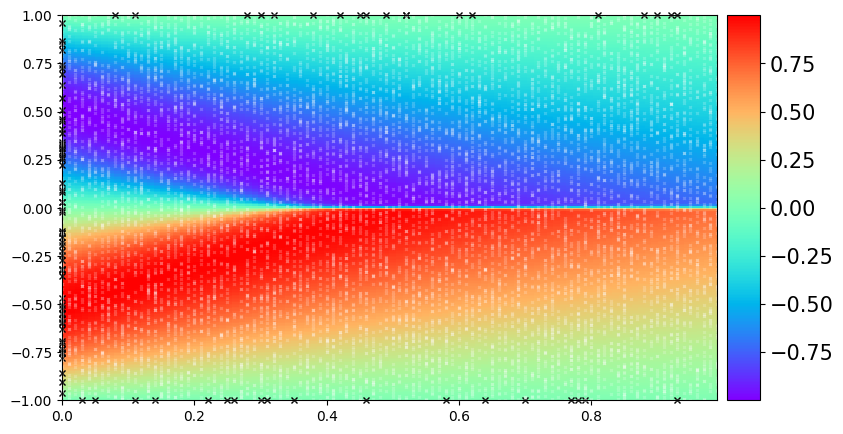

In [277]:
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)

h = ax.imshow(
    Exact.T,
    interpolation="nearest",
    cmap="rainbow",
    extent=[t.min(), t.max(), x.min(), x.max()],
    origin="lower",
    aspect="auto",
)

# h = ax.imshow(Exact.T, cmap='rainbow', origin='lower', aspect='auto') # Exact.T size (256,100), u(x,t) avec x[0] = -1
# plt.imshow(Exact.T[::-1,:], cmap='rainbow') # Pour avoir x = -1 en bas

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.10)
cbar = fig.colorbar(h, cax=cax)
cbar.ax.tick_params(labelsize=15)

ax.plot(
    t_train.cpu(),
    x_train.cpu(),
    "kx",
    label="Data (%d points)" % (u_train.shape[0]),
    markersize=4,  # marker size doubled
    clip_on=False,
    alpha=1.0,
)

ax.plot(
    t_train_f.cpu(),
    x_train_f.cpu(),
    "wx",
    markersize=2,  # marker size doubled
    clip_on=False,
    alpha=0.2,
)

plt.show()

## 1.3) Write the code of for $f_\theta$

We will use a simple fully connected neural network (NN) as $f_{\theta}$.
Use *e.g.* 8 hidden layers with tanh activation functions.



In [278]:
class DNN(torch.nn.Module):
    # À compléter...  

    def __init__(self, in_size = 2, hidden_size = 32, out_size = 1):
        super(DNN, self).__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(in_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, out_size),
        )

    def forward(self, x, t):
        B = x.shape[0]
        x_t_pairs = torch.cat((x,t), dim = 1)
        return self.layers(x_t_pairs)

dnn = DNN()
dnn.to(device)
print(x_train[:5], t_train[:5])
assert dnn(x_train[:5], t_train[:5]).shape == (
    5,
    1,
), f"{dnn(x_train[5:], t_train[5:]).shape}"

tensor([[-0.3569],
        [-0.7569],
        [-0.1765],
        [ 0.3333],
        [-0.3176]], device='cuda:0') tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')


In [279]:
print(dnn)

DNN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): Tanh()
    (8): Linear(in_features=32, out_features=32, bias=True)
    (9): Tanh()
    (10): Linear(in_features=32, out_features=32, bias=True)
    (11): Tanh()
    (12): Linear(in_features=32, out_features=32, bias=True)
    (13): Tanh()
    (14): Linear(in_features=32, out_features=32, bias=True)
    (15): Tanh()
    (16): Linear(in_features=32, out_features=32, bias=True)
    (17): Tanh()
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)



## 1.4) Write the code of the PhysicsInformedNN.

We will now implement the core class of this practical: the `PhysicsInformedNN`.

It will be predict the fonction $f_{\theta}(x,t)$, and the $h(f_{\theta}(x,t))$, where the latter is defined as:

$$h(f_{\theta}(x,t)) = \frac{\partial f_{\theta}(x,t)}{\partial t} + f_{\theta}(x,t) \frac{\partial f_{\theta}(x,t)}{\partial x} - \nu \frac{\partial^2 f_{\theta}(x,t)}{\partial x^2}$$

Note that you need to use [`torch.autograd.grad`](https://pytorch.org/docs/stable/generated/torch.autograd.grad.html) to compute derivatives and second order derivatives.

The `forward` function will return both $f_{\theta}(x,t)$ and $h(f_{\theta}(x,t))$.


In [280]:
# the physics-guided neural network
class PhysicsInformedNN(torch.nn.Module):
    def __init__(self, dnn: DNN, nu: float):
        super().__init__()

        # nu = viscosity
        self.nu = nu
        self.dnn = dnn


    def forward(self, x: torch.Tensor, t: torch.Tensor):
        # À compléter...  
        
        u = self.dnn(x, t)

        # time derivative
        u_t = torch.autograd.grad(u, t, create_graph = True, retain_graph=True, grad_outputs=torch.ones_like(u))[0]

        # first space derivation
        u_x = torch.autograd.grad(u, x, create_graph = True, retain_graph=True, grad_outputs=torch.ones_like(u))[0]

        # second space derivation
        u_xx = torch.autograd.grad(u_x, x, create_graph = True, retain_graph=True, grad_outputs=torch.ones_like(u))[0]

        f = u_t + u*u_x - self.nu*u_xx
        
        return u, f

    @contextmanager
    def eval_mode(self):
        """Use this to put the model in evaluation mode"""
        training = self.training
        if training:
            self.eval()
        yield
        if training:
            self.train()

    def predict(self, x: torch.Tensor, t: torch.Tensor):
        with self.eval_mode():
            u, f = self(x, t)
            u = u.detach().cpu().numpy()
            f = f.detach().cpu().numpy()
            return u, f


model = PhysicsInformedNN(dnn, 0.01 / np.pi).to(device)

u, f = model(x_train[:5], t_train[:5])
assert u.shape == (5, 1) and f.shape == (5, 1)

## 1.5) Write the code of the pinns_loss to train the PhysicsInformedNN

The `pinss_loss` function should return

- The global loss $\lambda_u L_u + \lambda_f L_f$
- The supervised loss $l_u(\theta) = \frac{1}{N_u} \sum\limits_{i=1}^{N_u} \left[f_{\theta}(x_i,t_i)-u_i(x_i,t_i)\right]^2$
- The unsupervised loss $l_f(\theta) = \frac{1}{N_f} \sum\limits_{i=1}^{N_f} \left[h_{\theta}(x_i,t_i)\right]^2 $

The final loss in PINNs will be a combination of both supervised and unsupervised  losses:

$$
\mathcal{L}(\theta) = \lambda_u l_u(\theta) + \lambda_fl_f(\theta)
$$


In [281]:
def pinns_loss(
    u_pred: torch.Tensor,
    u_target: torch.Tensor,
    f_pred: torch.Tensor,
    lambda_u=1.0,
    lambda_f=1.0,
):
    # À compléter...  

    loss_u = torch.mean((u_pred - u_target) ** 2)

    loss_f = torch.mean(f_pred ** 2)
    
    loss = lambda_u*loss_u + lambda_f*loss_f
    
    return loss, loss_u, loss_f

## 1.6) Train the model!

You can use a standard Adam optimizer, or to speed-up convergence a
[L-BFGS](https://en.wikipedia.org/wiki/Limited-memory_BFGS). In case of LBFGS,
you need to use a closure when calling the step method. This closure will do
the forward, and -- when computing the gradient -- the forward pass (zero the
gradient and perform the backward):

```python
def loss_closure():
  if torch.is_grad_enabled():
    optimizer.zero_grad()

  loss = ...

  if loss.requires_grad:
    loss.backward()

  return loss

optimizer.step(loss_closure)
```

This closure can be used also when using `Adam` or any other optimizer.


In [ ]:
x_train.requires_grad = True
t_train.requires_grad = True

In [304]:
# Start with ADAM

lambda_u = 1.0
lambda_f = 1.0
epochs = 5000

dnn = DNN()
model = PhysicsInformedNN(dnn, 0.01 / np.pi).to(device)
adam = torch.optim.Adam(model.parameters(), lr=1e-3)

for i in range(epochs):
    adam.zero_grad()
    u_pred, _ = model(x_train, t_train)
    _, f_pred = model(x_train_f, t_train_f)
    loss, _, _ = pinns_loss(u_pred, u_train, f_pred, lambda_u, lambda_f)
    loss.backward()
    adam.step()

    if i % 500 == 0:
        print(f"loss at epoch {i} : {loss}")

loss at epoch 0 : 0.3345566987991333
loss at epoch 500 : 0.04038338363170624
loss at epoch 1000 : 0.01387837901711464
loss at epoch 1500 : 0.005698466673493385
loss at epoch 2000 : 0.0035415468737483025
loss at epoch 2500 : 0.0017955994699150324
loss at epoch 3000 : 0.0013410928659141064
loss at epoch 3500 : 0.001073202583938837
loss at epoch 4000 : 0.0032918527722358704
loss at epoch 4500 : 0.0006524641066789627


In [305]:
# Continue with LBFGS

# À compléter...  
def loss_closure():

    u_pred, _ = model(x_train, t_train)
    _, f_pred = model(x_train_f, t_train_f)
    
    if torch.is_grad_enabled():
        optimizer.zero_grad()
    
    loss, _, _ = pinns_loss(u_pred, u_train, f_pred, lambda_u, lambda_f)

    if loss.requires_grad:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    return loss

lambda_u = 1.0
lambda_f = 1.0
epochs = 200

# dnn = DNN()
# model = PhysicsInformedNN(dnn, 0.01 / np.pi).to(device)
optimizer = torch.optim.LBFGS(model.parameters(), lr=1.0)

for i in range(epochs):
    loss = optimizer.step(loss_closure)

    if i % 50 == 0:
        print(f"loss at epoch {i} : {loss}")

loss at epoch 0 : 0.0005689545068889856
loss at epoch 50 : 2.261751978949178e-05
loss at epoch 100 : 7.78773937781807e-06
loss at epoch 150 : 4.390480171423405e-06



## 1.7) Asses the performances of the model!

- Visually assess the prediction on the  $(x,t)$ plane
- Compute the mean prediction error, and the error in the $(x,t)$ plane
- the prediction error over time slices at $t=0$, $t=25$, $t=50$, $t=75$


### Visually assess the prediction on the  $(x,t)$ plane

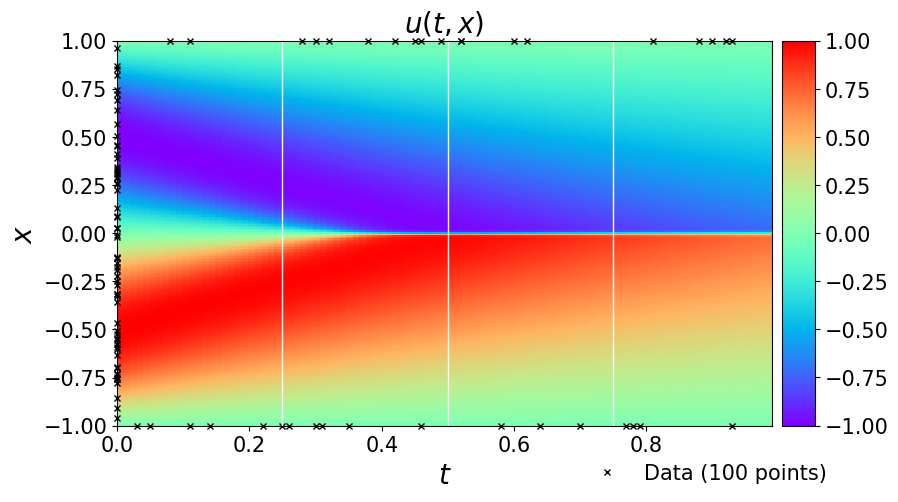

In [306]:

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)

u_pred, f_pred = model.predict(x_star, t_star)

U_pred = griddata(X_star, u_pred.flatten(), (X, T), method="cubic")

# learned heat map
h = ax.imshow(
    U_pred.T,
    interpolation="nearest",
    cmap="rainbow",
    extent=[t.min(), t.max(), x.min(), x.max()],
    origin="lower",
    aspect="auto",
)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.10)
cbar = fig.colorbar(h, cax=cax)
cbar.ax.tick_params(labelsize=15)

# training data points
ax.plot(
    t_train.cpu().detach().numpy(),
    x_train.cpu().detach().numpy(),
    "kx",
    label="Data (%d points)" % (u_train.shape[0]),
    markersize=4,  # marker size doubled
    clip_on=False,
    alpha=1.0,
)

line = np.linspace(x.min(), x.max(), 2)[:, None]
ax.plot(t[25] * np.ones((2, 1)), line, "w-", linewidth=1)
ax.plot(t[50] * np.ones((2, 1)), line, "w-", linewidth=1)
ax.plot(t[75] * np.ones((2, 1)), line, "w-", linewidth=1)

ax.set_xlabel("$t$", size=20)
ax.set_ylabel("$x$", size=20)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.9, -0.05),
    ncol=5,
    frameon=False,
    prop={"size": 15},
)
ax.set_title("$u(t,x)$", fontsize=20)  # font size doubled
ax.tick_params(labelsize=15)

plt.show()


### Compute the mean prediction error

Use the next cell to compute the prediction error for each $(x,t)$. You should
get an image similar to

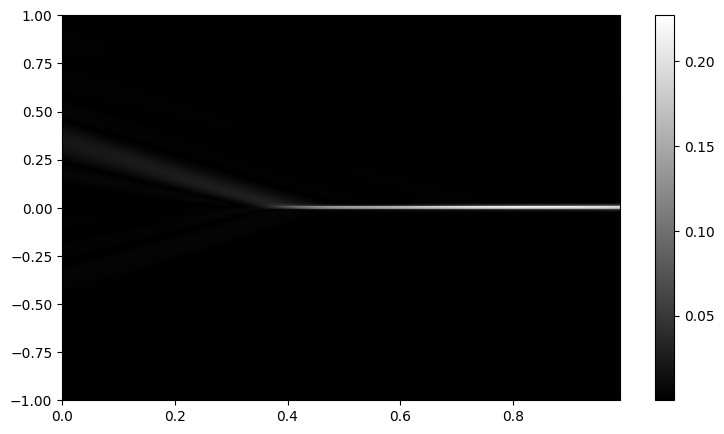

Error u: 3.075921e-03


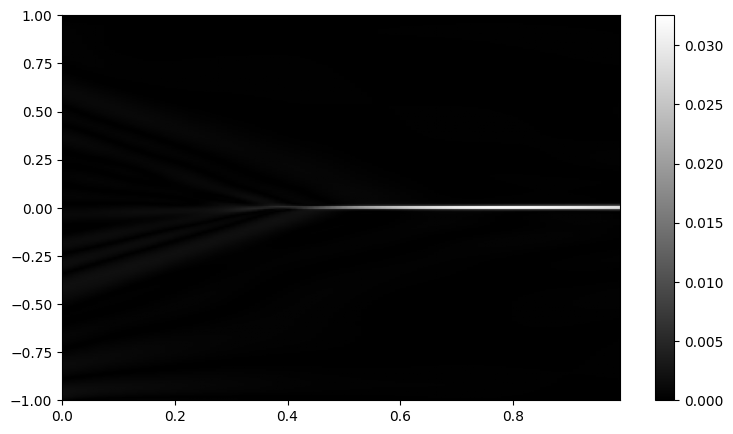

In [307]:
error_u = np.linalg.norm(u_star - u_pred.flatten(), 2) / np.linalg.norm(u_star, 2)
print("Error u: %e" % (error_u))

# U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')
Error = np.abs(Exact - U_pred)

####### Error in the $(x,t)$ planefig = plt.figure(figsize=(9, 5))
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)
h = ax.imshow(Error.T, extent=extent, origin="lower", aspect="auto", cmap="gray")
cbar = fig.colorbar(h)
plt.show()

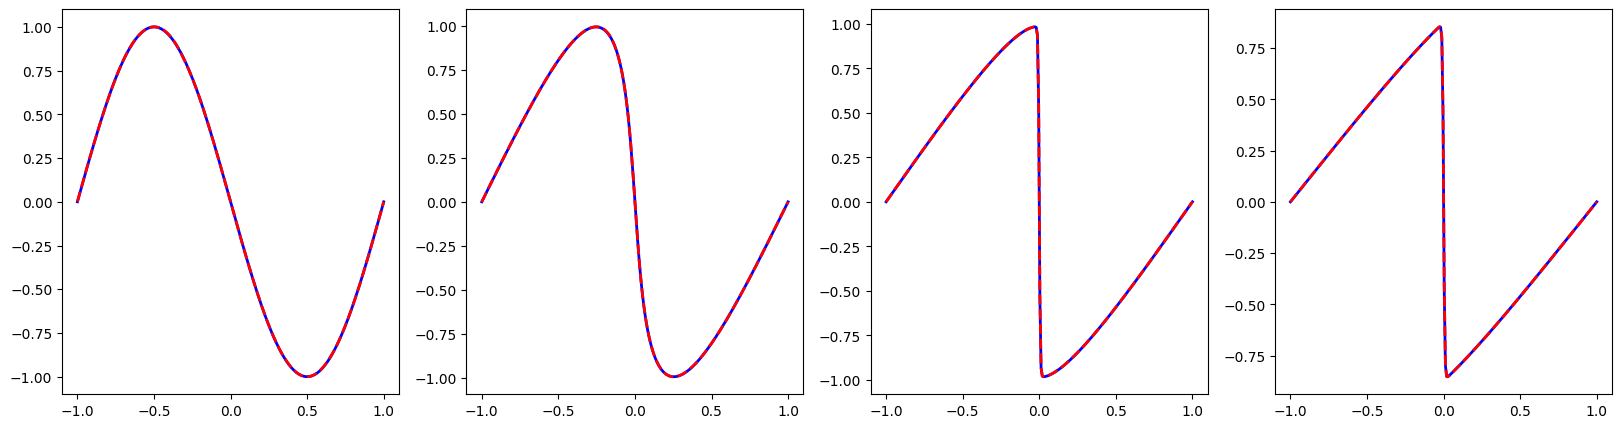

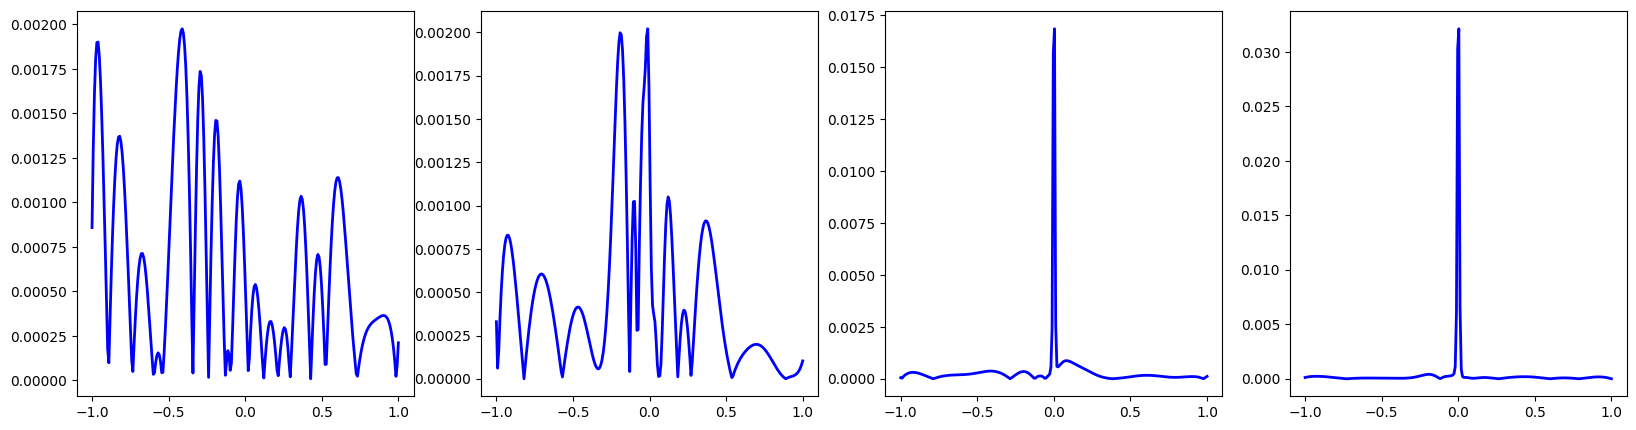

In [308]:
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(141)

# Target vs prediction from t=0 to t=25
ax.plot(x, Exact[0, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[0, :], "r--", linewidth=2, label="Prediction")

# Target vs prediction from t=25 to t=50
ax = fig.add_subplot(142)
ax.plot(x, Exact[25, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[25, :], "r--", linewidth=2, label="Prediction")

# Target vs prediction from t=50 to t=75
ax = fig.add_subplot(143)
ax.plot(x, Exact[50, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[50, :], "r--", linewidth=2, label="Prediction")

# Target vs prediction from t=75 to t=100
ax = fig.add_subplot(144)
ax.plot(x, Exact[75, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[75, :], "r--", linewidth=2, label="Prediction")



fig = plt.figure(figsize=(20, 5))
# error from t=0 to t=25
ax = fig.add_subplot(141)
ax.plot(x, Error[0, :], "b-", linewidth=2, label="Erreur")

# error from t=25 to t=50
ax = fig.add_subplot(142)
ax.plot(x, Error[25, :], "b-", linewidth=2, label="Erreur")

# error from t=50 to t=75
ax = fig.add_subplot(143)
ax.plot(x, Error[50, :], "b-", linewidth=2, label="Erreur")

# error from t=75 to t=100
ax = fig.add_subplot(144)
ax.plot(x, Error[75, :], "b-", linewidth=2, label="Erreur")

# print(Error[75,100:150])

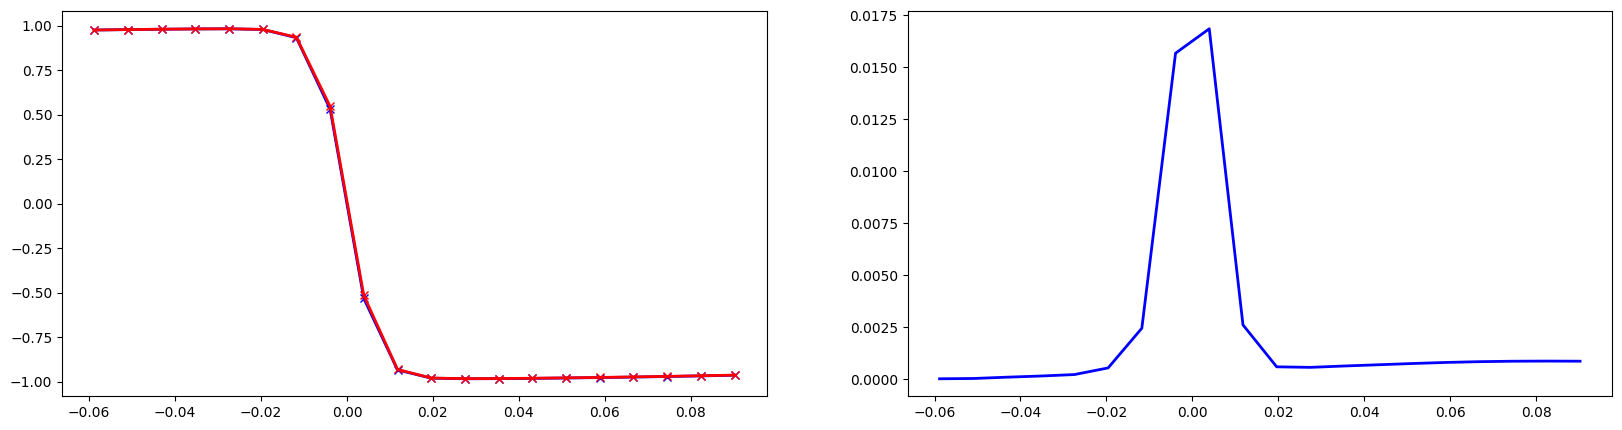

In [309]:
############# Close-up on slide at t=50
index = 50
min = 120
max = 140
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(121)
ax.plot(x[min:max], Exact[index, min:max], "b-x", linewidth=2, label="Exact")
ax.plot(x[min:max], U_pred[index, min:max], "r-x", linewidth=2, label="Prediction")

ax = fig.add_subplot(122)
ax.plot(x[min:max], Error[index, min:max], "b-", linewidth=2, label="Exact")


## 1.8) Train a prediction model without adding any constraint (fully data-driven model). Conclude.

In [310]:
lambda_u = 1.0
lambda_f = 0

# Start with ADAM

print("---------------------ADAM training---------------------")

epochs = 5000

dnn = DNN()
model = PhysicsInformedNN(dnn, 0.01 / np.pi).to(device)
adam = torch.optim.Adam(model.parameters(), lr=1e-3)

for i in range(epochs):
    adam.zero_grad()
    u_pred, _ = model(x_train, t_train)
    _, f_pred = model(x_train_f, t_train_f)
    loss, _, _ = pinns_loss(u_pred, u_train, f_pred, lambda_u, lambda_f)
    loss.backward()
    adam.step()

    if i % 500 == 0:
        print(f"loss at epoch {i} : {loss}")

print("---------------------LBFGS training---------------------")

epochs = 200

optimizer = torch.optim.LBFGS(model.parameters(), lr=1.0)

for i in range(epochs):
    loss = optimizer.step(loss_closure)

    if i % 50 == 0:
        print(f"loss at epoch {i} : {loss}")

---------------------ADAM training---------------------
loss at epoch 0 : 0.34023845195770264
loss at epoch 500 : 0.0009730022284202278
loss at epoch 1000 : 0.0016437872545793653
loss at epoch 1500 : 1.6596537534496747e-05
loss at epoch 2000 : 1.1418615031288937e-05
loss at epoch 2500 : 0.00014589641068596393
loss at epoch 3000 : 9.855611097009387e-06
loss at epoch 3500 : 7.599114906042814e-05
loss at epoch 4000 : 1.1640740012808237e-05
loss at epoch 4500 : 1.5460662325494923e-05
---------------------LBFGS training---------------------
loss at epoch 0 : 1.1701469702529721e-05
loss at epoch 50 : 2.8805568490497535e-06
loss at epoch 100 : 2.8805568490497535e-06
loss at epoch 150 : 2.8805568490497535e-06


Error u: 7.074912e-01


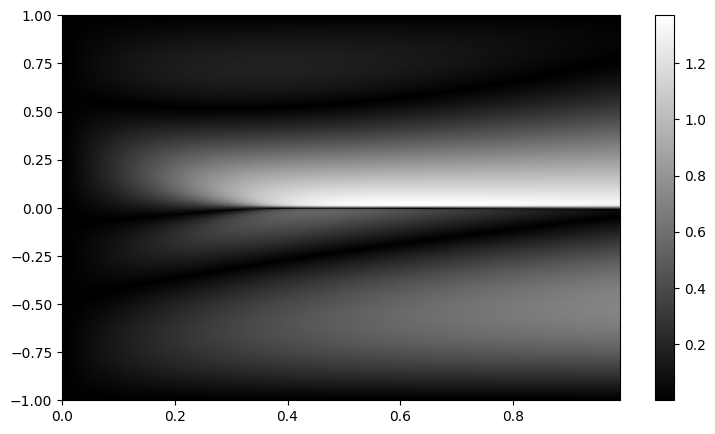

In [311]:
####### Compute the mean prediction error
u_pred, f_pred = model.predict(x_star, t_star)

error_u = np.linalg.norm(u_star - u_pred.flatten(), 2) / np.linalg.norm(u_star, 2)
print("Error u: %e" % (error_u))


U_pred = griddata(X_star, u_pred.flatten(), (X, T), method="cubic")
Error = np.abs(Exact - U_pred)

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)
h = ax.imshow(
    Error.T,
    extent=[t.min(), t.max(), x.min(), x.max()],
    origin="lower",
    aspect="auto",
    cmap="gray",
)
cbar = fig.colorbar(h)
plt.show()

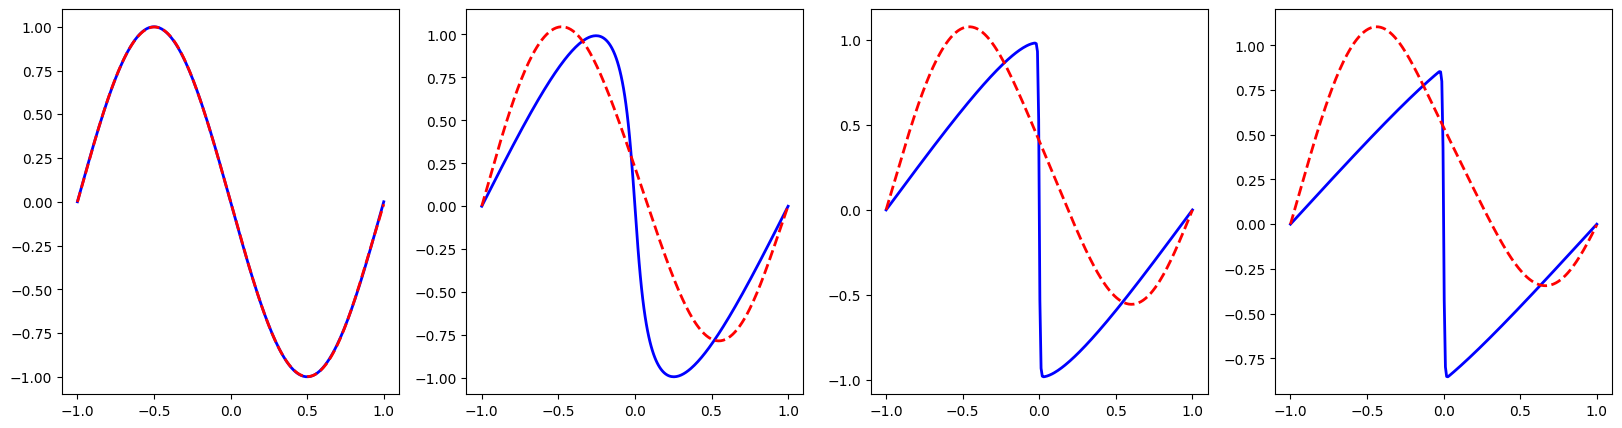

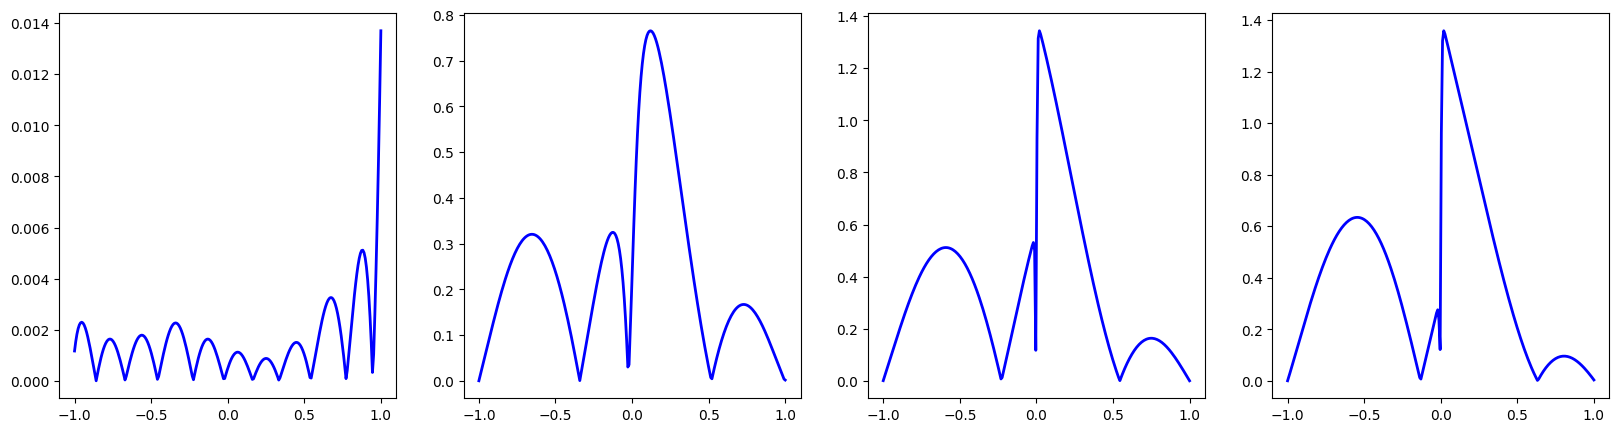

In [312]:
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(141)
ax.plot(x, Exact[0, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[0, :], "r--", linewidth=2, label="Prediction")

ax = fig.add_subplot(142)
ax.plot(x, Exact[25, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[25, :], "r--", linewidth=2, label="Prediction")

ax = fig.add_subplot(143)
ax.plot(x, Exact[50, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[50, :], "r--", linewidth=2, label="Prediction")


ax = fig.add_subplot(144)
ax.plot(x, Exact[75, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[75, :], "r--", linewidth=2, label="Prediction")

fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(141)
ax.plot(x, Error[0, :], "b-", linewidth=2, label="Erreur")

ax = fig.add_subplot(142)
ax.plot(x, Error[25, :], "b-", linewidth=2, label="Erreur")

ax = fig.add_subplot(143)
ax.plot(x, Error[50, :], "b-", linewidth=2, label="Erreur")

ax = fig.add_subplot(144)
ax.plot(x, Error[75, :], "b-", linewidth=2, label="Erreur")


# Exercice 2: physical parameter identification with PINNs

Remind that Burgers equation are driven by the following PDE :

$$\frac{\partial u(x,t)}{\partial t} + a  ~ u(x,t) ~ \frac{\partial
u(x,t)}{\partial x} - \nu  ~ \frac{\partial^2 u(x,t)}{\partial x^2} =0$$

In the previous part, we supposed that $a$ and $\nu$ were known. In this
exercice,


**We will augment the PhysicsInformedNN to estimate the physical parameters
$\nu$ and $a$**


## 2.1) Write the code for getting training data

We randomly sample $N_u=500$ points on the (x,t) plane on which we will apply
*both* the labeled $l_u$ and unlabeled $l_f$ losses. Note that contrary to the
previous exercise, we don't sample on the boundary.


In [370]:

# Identification de paramètres physiques
np.random.seed(1234)
N_u = 500  # Number of points to compute the prediction loss (MSE_u)

# À compléter...  
idx = torch.randint(0, X_star.size(0), (N_u,))

x_train_uf = torch.Tensor([X_star[i][0] for i in idx]).view(N_u, 1)
print("x_train shape: ", x_train_uf.shape)

t_train_uf = torch.Tensor([X_star[i][1] for i in idx]).view(N_u, 1)
print("t_train shape: ", t_train_uf.shape)
 
u_train_uf = torch.Tensor([u_star[i] for i in idx])
print("u_train shape: ", u_train_uf.shape)

x_train_f.requires_grad = True
t_train_f.requires_grad = True

assert x_train_uf.shape == (N_u, 1), f"{x_train_uf.shape}"
assert t_train_uf.shape == (N_u, 1), f"{t_train_uf.shape}"
assert u_train_uf.shape == (N_u,), f"{u_train_uf.shape} vs {N_u}"

x_train_uf, t_train_uf, u_train_uf = prepare(x_train_uf, t_train_uf, u_train_uf)

x_train shape:  torch.Size([500, 1])
t_train shape:  torch.Size([500, 1])
u_train shape:  torch.Size([500])


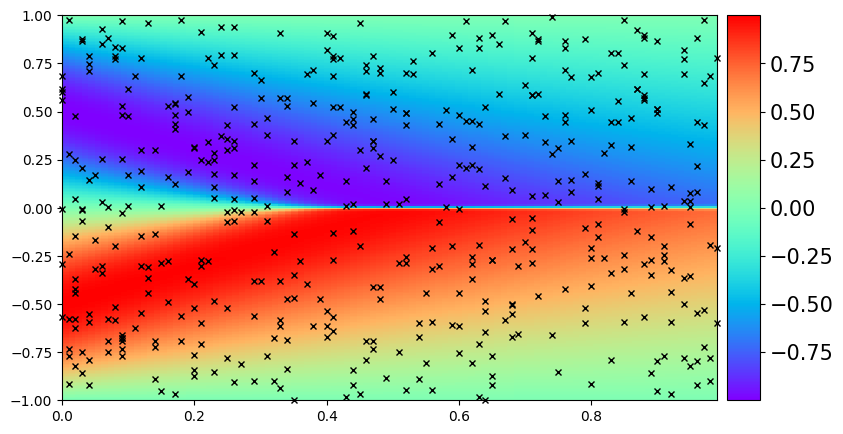

In [371]:
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)
h = ax.imshow(
    Exact.T,
    interpolation="nearest",
    cmap="rainbow",
    extent=extent,
    origin="lower",
    aspect="auto",
)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.10)
cbar = fig.colorbar(h, cax=cax)
cbar.ax.tick_params(labelsize=15)

ax.plot(
    t_train_uf.cpu(),
    x_train_uf.cpu(),
    "kx",
    label="Data (%d points)" % (u_train.shape[0]),
    markersize=4,  # marker size doubled
    clip_on=False,
    alpha=1.0,
)

plt.show()

## 2.2) Create a new PhysicsInformedNN_ID with trainable parameters to estimate $\nu$ and $a$

In [379]:
# the physics-guided neural network

# À compléter...  
class PhysicsInformedNN_ID(torch.nn.Module):
    def __init__(self, dnn: DNN):
        super().__init__()

        self.dnn = dnn

    # enforces positivity
        self.a_raw = nn.Parameter(torch.tensor(0.0))
        self.v_raw = nn.Parameter(torch.tensor(-3.0))

    def a(self):
        return torch.exp(self.a_raw)

    def v(self):
        return torch.exp(self.v_raw)


    def forward(self, x: torch.Tensor, t: torch.Tensor):
        # À compléter...  
        
        u = self.dnn(x, t)

        # time derivative
        u_t = torch.autograd.grad(u, t, create_graph = True, retain_graph=True, grad_outputs=torch.ones_like(u))[0]

        # first space derivation
        u_x = torch.autograd.grad(u, x, create_graph = True, retain_graph=True, grad_outputs=torch.ones_like(u))[0]

        # second space derivation
        u_xx = torch.autograd.grad(u_x, x, create_graph = True, retain_graph=True, grad_outputs=torch.ones_like(u))[0]

        f = u_t + self.a()*u*u_x - self.v()*u_xx
        
        return u, f

    @contextmanager
    def eval_mode(self):
        """Use this to put the model in evaluation mode"""
        training = self.training
        if training:
            self.eval()
        yield
        if training:
            self.train()

    def predict(self, x: torch.Tensor, t: torch.Tensor):
        with self.eval_mode():
            u, f = self(x, t)
            u = u.detach().cpu().numpy()
            f = f.detach().cpu().numpy()
            return u, f

## 2.3) Train the model

In [386]:
# Adding normalization to try and stabilize the results

x_mean, x_std = x_train_uf.mean(), x_train_uf.std()
t_mean, t_std = t_train_uf.mean(), t_train_uf.std()
u_mean, u_std = u_train_uf.mean(), u_train_uf.std()

x_train_uf = (x_train_uf - x_mean) / x_std
t_train_uf = (t_train_uf - t_mean) / t_std
u_train_uf = (u_train_uf - u_mean) / u_std

In [423]:
lambda_u = 1.0
lambda_f = 1

print("---------------------ADAM training---------------------")

epochs = 6000

dnn = DNN()
model = PhysicsInformedNN_ID(dnn).to(device)
adam = torch.optim.Adam(model.parameters(), lr=1e-4)

for i in range(epochs):
    adam.zero_grad()
    u_pred, _ = model(x_train, t_train)
    _, f_pred = model(x_train_f, t_train_f)
    loss, _, _ = pinns_loss(u_pred, u_train, f_pred, lambda_u, lambda_f)
    loss.backward()
    adam.step()

    if i % 500 == 0:
        print(f"loss at epoch {i} : {loss}")

---------------------ADAM training---------------------
loss at epoch 0 : 0.34046411514282227
loss at epoch 500 : 0.11836262047290802
loss at epoch 1000 : 0.022787557914853096
loss at epoch 1500 : 0.009249264374375343
loss at epoch 2000 : 0.004512780345976353
loss at epoch 2500 : 0.0031095421873033047
loss at epoch 3000 : 0.0027751163579523563
loss at epoch 3500 : 0.002132156863808632
loss at epoch 4000 : 0.001666648662649095
loss at epoch 4500 : 0.0013606136199086905
loss at epoch 5000 : 0.0011242710752412677
loss at epoch 5500 : 0.0009375032968819141


## 2.4) Evaluate prediction performances and physical parameter extimation quality

In [424]:
### PYSICAL PARAMETER IDENTIFICATION

# À compléter...  

print("True parameters:")
print("a = 1.0")
print(f"v = {0.01 / np.pi:.3f}")
print("----------------------------------------------------")
a_pred = model.a().detach().cpu().item()
v_pred = model.v().detach().cpu().item()

print("Estimated physical parameters:")
print(f"a prediction = {a_pred:.3f}")
print(f"v prediction = {v_pred:.3f}")
print("----------------------------------------------------")
print("Relative errors:")
print(f"a error = {abs(a_pred - 1.0):.3e}")
print(f"v error = {abs(v_pred - 0.01/np.pi):.3e}")

True parameters:
a = 1.0
v = 0.003
----------------------------------------------------
Estimated physical parameters:
a prediction = 0.737
v prediction = 0.058
----------------------------------------------------
Relative errors:
a error = 2.635e-01
v error = 5.487e-02


Error u: 3.258262e-01
Error u: 3.819272e-01


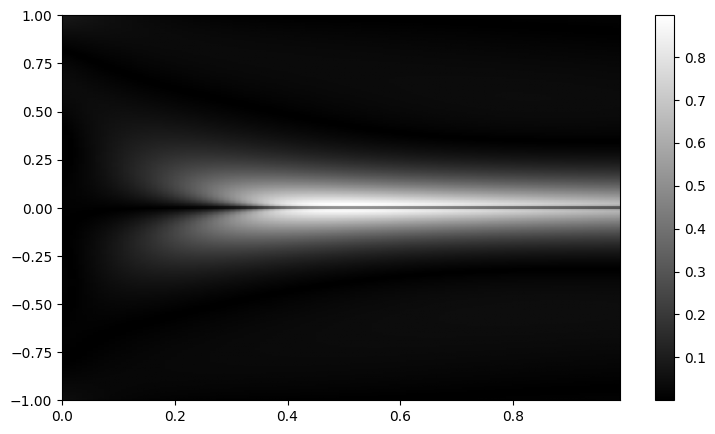

In [425]:
### FORECAST QUALITY
u_pred, f_pred = model.predict(x_star, t_star)
u_pred = u_pred.flatten()

error_u = np.linalg.norm(u_star - u_pred, 2) / np.linalg.norm(u_star, 2)
print("Error u: %e" % (error_u))

U_pred = griddata(X_star, u_pred, (X, T), method="cubic")
Error = np.abs(Exact - U_pred)
error_u2 = np.linalg.norm(Exact - U_pred, "fro") / np.linalg.norm(U_pred, "fro")
print("Error u: %e" % (error_u2))

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)
h = ax.imshow(
    Error.T,
    extent=[t.min(), t.max(), x.min(), x.max()],
    origin="lower",
    aspect="auto",
    cmap="gray",
)
cbar = fig.colorbar(h)
plt.show()

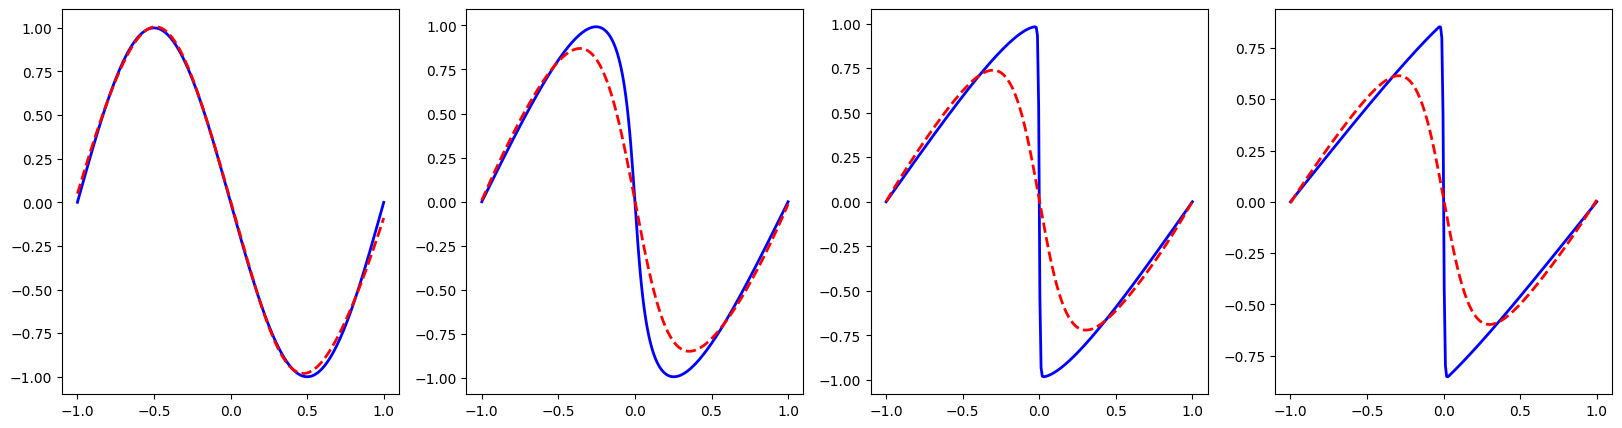

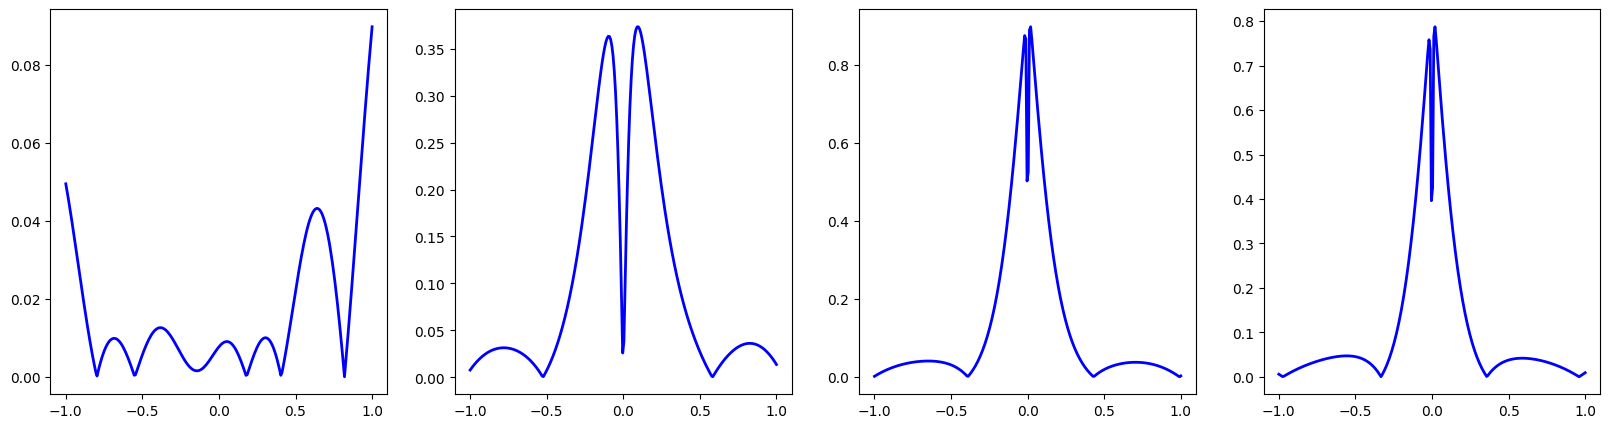

In [426]:
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(141)
ax.plot(x, Exact[0, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[0, :], "r--", linewidth=2, label="Prediction")

ax = fig.add_subplot(142)
ax.plot(x, Exact[25, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[25, :], "r--", linewidth=2, label="Prediction")

ax = fig.add_subplot(143)
ax.plot(x, Exact[50, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[50, :], "r--", linewidth=2, label="Prediction")


ax = fig.add_subplot(144)
ax.plot(x, Exact[75, :], "b-", linewidth=2, label="Exact")
ax.plot(x, U_pred[75, :], "r--", linewidth=2, label="Prediction")

fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(141)
ax.plot(x, Error[0, :], "b-", linewidth=2, label="Erreur")

ax = fig.add_subplot(142)
ax.plot(x, Error[25, :], "b-", linewidth=2, label="Erreur")

ax = fig.add_subplot(143)
ax.plot(x, Error[50, :], "b-", linewidth=2, label="Erreur")

ax = fig.add_subplot(144)
ax.plot(x, Error[75, :], "b-", linewidth=2, label="Erreur")

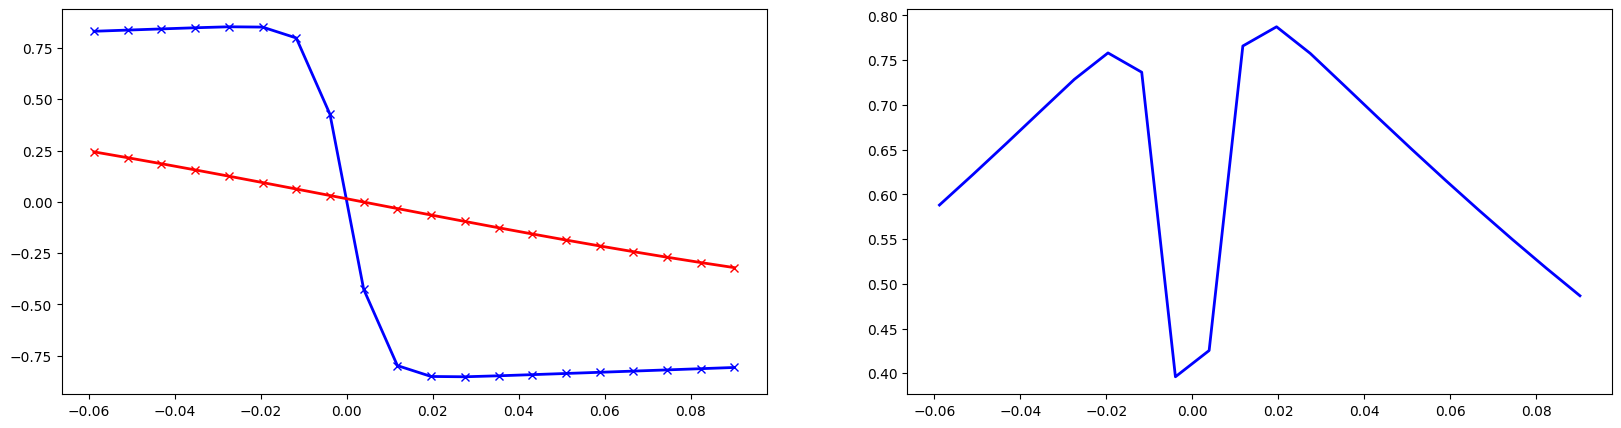

In [427]:
index = 75
min = 120
max = 140
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(121)
ax.plot(x[min:max], Exact[index, min:max], "b-x", linewidth=2, label="Exact")
ax.plot(x[min:max], U_pred[index, min:max], "r-x", linewidth=2, label="Prediction")

ax = fig.add_subplot(122)
ax.plot(x[min:max], Error[index, min:max], "b-", linewidth=2, label="Exact")